# MonarQ hardware: simulator-side characterization and real hardware results

Phase 3. Most of this notebook runs against `monarq.sim` (the plugin's noise-model simulator) or read-only calibration queries, used to figure out what circuit depth/system size was actually viable before spending real hardware time on something noise would drown out anyway. The last section reports the real `monarq.default` results that plan led to.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from src.vqe import train_vqe, evaluate_on_device
from src.exact import ground_state_energy
from src.mitigation import MACHINE_NAME, measure_raw_and_mitigated, repeat_raw_and_mitigated

# One colourblind-safe palette for every figure here. Series also get their own
# marker shape or hatching, so identity never rests on colour alone.
COLORS = {2: "#0072B2", 4: "#D55E00", 6: "#009E73"}
MARKERS = {2: "o", 4: "s", 6: "^"}
RAW_COLOR, MITIGATED_COLOR = "#0072B2", "#D55E00"

## Current calibration

Read-only metadata query (`ApiAdapter.get_qubits_and_couplers`) — no job submitted. The roadmap flagged that the qubit *count* was settled but which physical qubits carry it can drift, so this gets re-checked rather than assumed.

The same client is needed further down. `monarq.sim` only builds its noise model from MonarQ's real calibration when it is handed one, and readout mitigation cannot work at all without it.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(REPO_ROOT / "local_only" / ".env")

from pennylane_calculquebec.API.client import CalculQuebecClient
from pennylane_calculquebec.API.adapter import ApiAdapter

client = CalculQuebecClient(
    host=os.environ["MONARQ_HOST"],
    user=os.environ["MONARQ_USER"],
    access_token=os.environ["MONARQ_TOKEN"],
    project_id=os.environ["MONARQ_PROJECT_ID"],
)
client.machine_name = MACHINE_NAME
ApiAdapter.initialize(client)

calibration = ApiAdapter.get_qubits_and_couplers(MACHINE_NAME)
usable_qubits = [q for q, v in calibration["qubits"].items() if v["singleQubitGateFidelity"] > 0]
usable_couplers = [c for c, v in calibration["couplers"].items() if v["czGateFidelity"] > 0]
print(f"Usable qubits: {sorted(usable_qubits, key=int)}")
print(f"Usable couplers: {sorted(usable_couplers, key=int)}")
print()
for q in sorted(usable_qubits, key=int):
    v = calibration["qubits"][q]
    print(f"  qubit {q}: 1q_fidelity={v['singleQubitGateFidelity']:.4f}  "
          f"readout0={v['readoutState0Fidelity']:.3f}  readout1={v['readoutState1Fidelity']:.3f}")
for c in sorted(usable_couplers, key=int):
    print(f"  coupler {c}: cz_fidelity={calibration['couplers'][c]['czGateFidelity']:.4f}")

Usable qubits: ['9', '10', '11', '12', '13', '14']
Usable couplers: ['15', '16', '17', '18', '19']

  qubit 9: 1q_fidelity=0.9965  readout0=0.975  readout1=0.917
  qubit 10: 1q_fidelity=0.9942  readout0=0.976  readout1=0.878
  qubit 11: 1q_fidelity=0.9960  readout0=0.975  readout1=0.876
  qubit 12: 1q_fidelity=0.9944  readout0=0.965  readout1=0.857
  qubit 13: 1q_fidelity=0.9962  readout0=0.915  readout1=0.908
  qubit 14: 1q_fidelity=0.9944  readout0=0.954  readout1=0.899
  coupler 15: cz_fidelity=0.9596
  coupler 16: cz_fidelity=0.9172
  coupler 17: cz_fidelity=0.9971
  coupler 18: cz_fidelity=0.9767
  coupler 19: cz_fidelity=0.9400


Still exactly 6 usable qubits and 5 couplers, matching the roadmap's last-known state — no drift since the original benchmark pull. Those five couplers wire the six qubits into one open chain, `12-9-13-10-14-11`, which is what the transpiler's placement step actually uses.

The other 18 qubits report all-zero calibration. That matters later: anything that reads a fidelity off a qubit MonarQ is not currently running gets a zero, and the plugin's readout mitigation quietly gives up when it does.

## A real plugin bug: multi-term Hamiltonian expval

`qml.expval(H)` for a multi-term `H` returns near-zero nonsense on `monarq.sim`, confirmed against a state with a known exact answer: two Hadamards (the HVA's own zero-layer starting state) give `|++>`, where `H = -Z0Z1 - X0 - X1` has exact expval -2.0 (`<X0>=<X1>=1`, `<Z0Z1>=0`).

In [3]:
from src.hamiltonian import build_pennylane_hamiltonian

H = build_pennylane_hamiltonian(L=2, h=1.0, J=1.0)
dev = qml.device("monarq.sim", wires=2)

@qml.qnode(dev, shots=1000)
def broken():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    return qml.expval(H)

print(f"qml.expval(H) directly: {broken():.4f}  (should be ~-2.0)")

qml.expval(H) directly: 0.4700  (should be ~-2.0)


/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/pennylane/transforms/tape_expand.py:90: PennyLaneDeprecationWarning: 
        The create_expand_fn is deprecated in PennyLane v0.45 and will be removed in v0.46.
        Please use the qp.transforms.decompose function for decomposing circuits.
        
  warnings.warn(


`src/vqe.py`'s `evaluate_on_device` works around this by measuring each Hamiltonian term separately and summing the weighted results in plain Python, which is correct. Zero HVA layers reduces to the same `|++>` state as above, so it should land on the same -2.0:

In [4]:
import numpy as np
E_workaround = evaluate_on_device(L=2, h=1.0, params=np.zeros((0, 2)), device="monarq.sim", shots=1000)
print(f"evaluate_on_device (per-term workaround): {E_workaround:.4f}  (should be ~-2.0)")

evaluate_on_device (per-term workaround): -1.8010  (should be ~-2.0)


## The noiseless baseline has to be trained properly first

Every point below compares a noisy `monarq.sim` measurement against the same circuit's noiseless energy, so that noiseless number has to be the best the ansatz can actually do. If it isn't, the "noise" being measured is partly just a bad optimization.

There is a cheap floor to check it against. At `params = 0` the HVA reduces to its Hadamard layer alone, giving `|+>^L`, where `<ZZ> = 0` and `<X> = 1` on every site — so `<H> = -h*L` exactly. Any trained energy worse than `-h*L` means the optimizer ended up somewhere worse than not optimizing at all.

An earlier pass through this ladder used one run at `seed=0` per point and tripped that floor three times. Retraining from 20 random starts shows why.

In [5]:
POINTS = [(2, 0.4, 1), (2, 1.0, 1), (2, 1.0, 2), (2, 1.0, 4), (2, 1.6, 1),
          (4, 1.0, 1), (4, 1.0, 2), (4, 1.0, 4),
          (6, 1.0, 1), (6, 1.0, 2), (6, 1.0, 4)]
SEEDS = list(range(20))
N_STEPS, STEPSIZE, SHOTS, N_REPEATS = 600, 0.1, 1000, 10
RESTART_DIR = REPO_ROOT / "results" / "monarq_sim_restarts"


def result_path(L, h, n_layers):
    """Where the retrained result for one (L, h, n_layers) point lives."""
    return RESTART_DIR / str(L) / f"{h:.3f}_layers{n_layers}.json"


def train_best_of_restarts(L, h, n_layers, seeds=SEEDS):
    """Train the HVA once per seed and keep the lowest energy found.

    Returns the whole picture, not just the winner: every seed's energy, which
    seed won, and the params=0 floor to sanity-check the winner against.
    """
    energies = {seed: float(train_vqe(L=L, h=h, n_layers=n_layers, n_steps=N_STEPS,
                                      stepsize=STEPSIZE, seed=seed)[0])
                for seed in seeds}
    best_seed = min(energies, key=energies.get)
    best = energies[best_seed]
    E_exact = ground_state_energy(L, h, J=1.0)
    return {
        "L": L, "h": h, "J": 1.0, "n_layers": n_layers,
        "method": "vqe_monarq_sim", "device": "monarq.sim", "boundary": "open",
        "two_qubit_gate_count": (L - 1) * n_layers,
        "E0_exact": float(E_exact),
        "params_zero_floor": -h * L,
        "n_restarts": len(seeds), "seeds": list(seeds), "best_seed": best_seed,
        "energies_by_seed": {str(s): e for s, e in energies.items()},
        "E0_sim_noiseless": best,
        "rel_error_sim": abs(best - E_exact) / abs(E_exact),
        "beats_params_zero_floor": bool(best <= -h * L),
        "n_steps": N_STEPS, "stepsize": STEPSIZE,
        "supersedes": f"results/monarq_sim/{L}/{h:.3f}_layers{n_layers}.json",
    }


# Resumable in the same way as the runners in src/: a point that already has a
# results file is loaded rather than retrained.
records = {}
for L, h, n_layers in POINTS:
    path = result_path(L, h, n_layers)
    if path.exists():
        records[(L, h, n_layers)] = json.loads(path.read_text())
        continue
    record = train_best_of_restarts(L, h, n_layers)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(record, indent=2))
    records[(L, h, n_layers)] = record

print(f"{'point':<24}{'seed 0':>10}{'best of 20':>12}{'floor':>8}{'exact':>10}{'below floor':>16}")
for r in records.values():
    label = f"L={r['L']}  h={r['h']}  layers={r['n_layers']}"
    below = sum(1 for e in r["energies_by_seed"].values() if e <= r["params_zero_floor"])
    below_str = f"{below}/{r['n_restarts']}"
    print(f"{label:<24}{r['energies_by_seed']['0']:>10.3f}{r['E0_sim_noiseless']:>12.3f}"
          f"{r['params_zero_floor']:>8.1f}{r['E0_exact']:>10.3f}{below_str:>16}")

point                       seed 0  best of 20   floor     exact     below floor
L=2  h=0.4  layers=1        -1.281      -1.281    -0.8    -1.281           20/20
L=2  h=1.0  layers=1        -2.236      -2.236    -2.0    -2.236           20/20
L=2  h=1.0  layers=2        -2.236      -2.236    -2.0    -2.236           20/20
L=2  h=1.0  layers=4        -2.236      -2.236    -2.0    -2.236           20/20
L=2  h=1.6  layers=1        -3.353      -3.353    -3.2    -3.353           20/20
L=4  h=1.0  layers=1        -0.187      -4.646    -4.0    -4.759           13/20
L=4  h=1.0  layers=2        -4.721      -4.735    -4.0    -4.759           20/20
L=4  h=1.0  layers=4        -4.758      -4.759    -4.0    -4.759           20/20
L=6  h=1.0  layers=1        -2.599      -7.060    -6.0    -7.296           10/20
L=6  h=1.0  layers=2        -2.617      -7.222    -6.0    -7.296           19/20
L=6  h=1.0  layers=4        -7.230      -7.279    -6.0    -7.296           20/20


Three points move a long way, and the shape of the failure is unusually clean.

| point | old, `seed=0` | best of 20 restarts | exact | seeds clearing the floor |
|---|---|---|---|---|
| `L=4`, 1 layer | −0.187 (96.1% error) | **−4.646 (2.4%)** | −4.759 | 13/20 |
| `L=6`, 1 layer | −2.599 (64.4%) | **−7.060 (3.2%)** | −7.296 | 10/20 |
| `L=6`, 2 layers | −2.617 (64.1%) | **−7.222 (1.0%)** | −7.296 | 19/20 |

The seed energies are not spread out, they are bimodal. At `L=6` with one layer, 10 of 20 seeds land on −7.060 and the other 10 land on −2.599, with nothing in between: the optimizer either finds the ground state or falls into one specific bad minimum, and a single run gives no signal about which happened. At `L=6` with two layers only one seed in 20 fails — and it is `seed=0`.

So the earlier reading of these points, that one HVA layer is not expressive enough at larger `L`, was wrong. One layer at `L=6` reaches within 3.2% of exact; it just needs a start that isn't `seed=0`. These were training failures, and the hardware-sim errors previously recorded against them (97%, 81%, 89%) were measuring a badly-trained state rather than device noise.

The `params = 0` floor is what makes this diagnosable at a glance, and it costs nothing: all three old values sat *above* −h·L, meaning the trained circuit was worse than the untrained one. Worth checking on any variational result before reading physics into it.

One caveat about the points that were already fine. Where the ansatz is over-parameterised — every `L=2` point here — many different parameter sets reach the same exact energy, and a restart picks a different one than `seed=0` did. The noiseless energy is identical but the circuit is not, so the noisy measurement of it can differ. That is why some already-converged points below do not exactly reproduce their old measured values.

## Noise vs. circuit depth, across the full hardware ladder

Trained the HVA in simulation (no hardware involved) at `L = 2, 4, 6` and `n_layers = 1, 2, 4` using the best-of-20 parameters above, then ran the *already-trained* circuit on `monarq.sim`. This is the real workflow: training never touches hardware (see `src/vqe.py`'s module docstring for why), only the final measurement does.

`monarq.sim` draws 1000 shots per Hamiltonian term, so one measurement of the energy carries a few percent of statistical error. Each point is therefore measured 10 times and reported as mean ± standard error rather than as a single number.

In [6]:
def measure_repeatedly(L, h, n_layers, best_seed, n_repeats=N_REPEATS):
    """Run one trained circuit on monarq.sim n_repeats times and return the energies.

    No client is passed, and that is deliberate: without one the plugin falls
    back to its generic `TypicalBenchmark` noise constants, which is the noise
    model this whole ladder was originally measured under. Keeping it makes the
    points comparable to each other.
    """
    _, _, params = train_vqe(L=L, h=h, n_layers=n_layers, n_steps=N_STEPS,
                             stepsize=STEPSIZE, seed=best_seed, return_params=True)
    return [evaluate_on_device(L, h, params, device="monarq.sim", shots=SHOTS)
            for _ in range(n_repeats)]


for (L, h, n_layers), r in records.items():
    if "E0_hardware_sim_values" in r:
        continue
    start = time.perf_counter()
    values = measure_repeatedly(L, h, n_layers, r["best_seed"])
    mean, sem = float(np.mean(values)), float(np.std(values, ddof=1) / np.sqrt(len(values)))
    r.update({
        "shots": SHOTS, "mitigation": "none", "noise_model": "typical_benchmark",
        "n_repeats": len(values),
        "E0_hardware_sim_values": values,
        "E0_hardware_sim": mean,
        "E0_hardware_sim_std": float(np.std(values, ddof=1)),
        "E0_hardware_sim_standard_error": sem,
        "rel_error_hardware_sim": abs(mean - r["E0_exact"]) / abs(r["E0_exact"]),
        "rel_error_hardware_sim_standard_error": sem / abs(r["E0_exact"]),
        "wall_time_s": time.perf_counter() - start,
    })
    result_path(L, h, n_layers).write_text(json.dumps(r, indent=2))

print(f"{'point':<24}{'2q gates':>9}{'noiseless':>11}{'monarq.sim energy':>24}{'hw-sim error':>18}")
for r in records.values():
    label = f"L={r['L']}  h={r['h']}  layers={r['n_layers']}"
    energy = f"{r['E0_hardware_sim']:.3f} +/- {r['E0_hardware_sim_standard_error']:.3f}"
    err = f"{r['rel_error_hardware_sim']:.1%} +/- {r['rel_error_hardware_sim_standard_error']:.1%}"
    print(f"{label:<24}{r['two_qubit_gate_count']:>9}{r['E0_sim_noiseless']:>11.3f}{energy:>24}{err:>18}")

point                    2q gates  noiseless       monarq.sim energy      hw-sim error
L=2  h=0.4  layers=1            1     -1.281        -0.707 +/- 0.007    44.8% +/- 0.5%
L=2  h=1.0  layers=1            1     -2.236        -1.452 +/- 0.008    35.1% +/- 0.3%
L=2  h=1.0  layers=2            2     -2.236        -1.019 +/- 0.011    54.4% +/- 0.5%
L=2  h=1.0  layers=4            4     -2.236        -0.698 +/- 0.011    68.8% +/- 0.5%
L=2  h=1.6  layers=1            1     -3.353        -2.245 +/- 0.017    33.1% +/- 0.5%
L=4  h=1.0  layers=1            3     -4.646        -2.658 +/- 0.013    44.1% +/- 0.3%
L=4  h=1.0  layers=2            6     -4.735        -1.852 +/- 0.018    61.1% +/- 0.4%
L=4  h=1.0  layers=4           12     -4.759        -0.878 +/- 0.020    81.6% +/- 0.4%
L=6  h=1.0  layers=1            5     -7.060        -3.900 +/- 0.014    46.5% +/- 0.2%
L=6  h=1.0  layers=2           10     -7.222        -2.562 +/- 0.028    64.9% +/- 0.4%
L=6  h=1.0  layers=4           20     -7.27

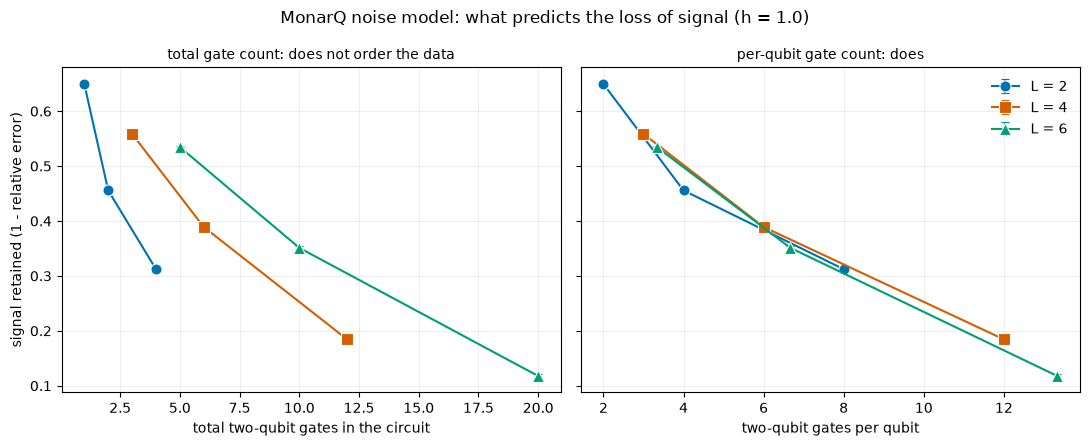

In [7]:
fig, (ax_total, ax_per_qubit) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for L in (2, 4, 6):
    pts = sorted((r["two_qubit_gate_count"], r["n_layers"],
                  1 - r["rel_error_hardware_sim"], r["rel_error_hardware_sim_standard_error"])
                 for r in records.values() if r["L"] == L and r["h"] == 1.0)
    gates, layers, retained, sem = zip(*pts)
    # Each IsingZZ transpiles to 2 native CZ, shared across L qubits.
    per_qubit = [4 * (L - 1) * n / L for n in layers]
    for ax, x in ((ax_total, gates), (ax_per_qubit, per_qubit)):
        ax.errorbar(x, retained, yerr=sem, marker=MARKERS[L], color=COLORS[L], markersize=8,
                    markeredgecolor="white", markeredgewidth=0.8, linewidth=1.5,
                    capsize=3, label=f"L = {L}")

ax_total.set_xlabel("total two-qubit gates in the circuit")
ax_per_qubit.set_xlabel("two-qubit gates per qubit")
ax_total.set_ylabel("signal retained (1 - relative error)")
ax_total.set_title("total gate count: does not order the data", fontsize=10)
ax_per_qubit.set_title("per-qubit gate count: does", fontsize=10)
for ax in (ax_total, ax_per_qubit):
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
ax_per_qubit.legend(frameon=False)
fig.suptitle("MonarQ noise model: what predicts the loss of signal (h = 1.0)")
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_noise_vs_gates.png", dpi=150)
plt.show()

Two things change once the baselines are trained properly.

The three repaired points drop sharply: `L=4`/1 layer from 97.0% to 44.1%, `L=6`/1 layer from 81.1% to 46.5%, `L=6`/2 layers from 88.7% to 64.9%. What was previously read as noise bad enough to erase the signal at low depth was mostly a badly-trained state.

More importantly, the corrected data does not support the conclusion drawn from the old version. That conclusion was that error lands in a similar place at matched two-qubit gate count regardless of `L`, and therefore that gate count is what drives the degradation. Sorted by total two-qubit gate count, the corrected retentions are not even monotonic:

| total 2q gates | 1 | 2 | 3 | 4 | 5 | 6 | 10 | 12 | 20 |
|---|---|---|---|---|---|---|---|---|---|
| signal retained | 0.649 | 0.456 | **0.559** | 0.312 | **0.535** | 0.389 | 0.351 | 0.184 | 0.118 |

Three gates (`L=4`, 1 layer) retains *more* signal than two (`L=2`, 2 layers), and five (`L=6`, 1 layer) retains more than four (`L=2`, 4 layers). Total gate count does not order the data.

Two-qubit gates **per qubit** does, monotonically and without exception — and it collapses the three `L` curves onto essentially a single line, which is the clearest way to see it in the right panel below. Each `IsingZZ` transpiles to 2 native `CZ`, so the circuit carries `2(L−1)n` CZ gates spread across `L` qubits — `4(L−1)n/L` each. That is `2n` at `L=2`, `3n` at `L=4` and `3.33n` at `L=6`: proportional to depth, but saturating in `L` towards `4n`. Which is exactly the observed behaviour. Quadrupling the depth is expensive; tripling the qubit count at fixed depth costs comparatively little.

Signal retention is the natural framing rather than "% error" because ⟨H⟩ = 0 for the maximally mixed state — every Pauli term is traceless — so zero retention is what total decoherence looks like, not an arbitrary reference point.

One more thing worth knowing before reading any number from this device. `monarq.sim` models gate noise as depolarizing channels and nothing else. `GateNoiseSimulation` computes amplitude- and phase-damping parameters from the calibration's T1 and T2 values and then never applies them:

In [8]:
from collections import Counter

from pennylane.tape import QuantumTape
from pennylane_calculquebec.processing import PreProcessor
from pennylane_calculquebec.processing.config import MonarqDefaultConfig
from pennylane_calculquebec.processing.steps import GateNoiseSimulation
from src.vqe import hva_layer

# Build the L=6 / 4-layer circuit, transpile it the way the device would, add the
# noise the device would add, then count what actually ended up in the tape.
with qml.queuing.AnnotatedQueue() as q:
    for w in range(6):
        qml.Hadamard(wires=w)
    for _ in range(4):
        hva_layer(0.7, 0.3, 6)
    qml.counts(wires=[0, 1])

tape = QuantumTape(*qml.queuing.process_queue(q), shots=1000)
config = MonarqDefaultConfig(MACHINE_NAME, use_benchmark=False)
transpiled = PreProcessor.get_processor(config, list(range(6)))(tape)[0][0]
noisy = GateNoiseSimulation(MACHINE_NAME, False).execute(transpiled)

print("operations in the tape monarq.sim hands to default.mixed:")
for name, count in sorted(Counter(op.name for op in noisy.operations).items(), key=lambda kv: -kv[1]):
    tag = "  <- noise" if "Channel" in name or "Damping" in name else ""
    print(f"  {name:<22}{count:>5}{tag}")

operations in the tape monarq.sim hands to default.mixed:
  DepolarizingChannel     310  <- noise
  X90                     118
  PauliZ                   68
  RZ                       44
  CZ                       40


`DepolarizingChannel` and nothing else. The simulator therefore has no time- or idle-dependent error at all, which is one concrete reason it should be expected to underestimate real hardware — and a reason its noise is a function of gate counts by construction, which is worth remembering when reading the per-qubit result above.

## Does readout error mitigation help?

The plugin ships `MatrixReadoutMitigation`, a calibration-matrix correction applied to the measured counts after a circuit runs. An earlier pass through this notebook appended it to the processing config, saw the energy barely move, and concluded that mitigation does not help here.

That conclusion was not supported, because the correction never ran. `MatrixReadoutMitigation.execute` wraps its body in `try/except`, logs whatever went wrong, and hands back the counts it was given — so a correction that failed outright looks exactly like one that ran and found nothing to fix. Two separate things were going wrong, and both were silent:

In [9]:
from pennylane.measurements import CountsMP
from pennylane.tape import QuantumTape
from pennylane_calculquebec.processing.steps.readout_error_mitigation import MatrixReadoutMitigation

counts = {"00": 500, "01": 100, "10": 100, "11": 300}

for wires, note in (([0, 1], "logical wires — MonarQ is not calibrating these"),
                    ([9, 10], "real qubits from the live chain")):
    # The plugin caches its calibration matrix on the class and only reconsiders
    # it once a day, so it has to be cleared between different sets of qubits.
    MatrixReadoutMitigation._readout_matrix_normalized = None
    MatrixReadoutMitigation._readout_matrix_reduced = None
    MatrixReadoutMitigation._readout_matrix_reduced_inverted = None

    tape = QuantumTape(ops=[], measurements=[CountsMP(wires=wires)], shots=1000)
    out = MatrixReadoutMitigation(MACHINE_NAME).execute(tape, counts)
    changed = any(out[k] != counts[k] for k in counts)
    print(f"wires {wires}  ({note})")
    print(f"    in : {counts}")
    print(f"    out: {dict((k, float(v)) for k, v in out.items())}")
    print(f"    counts changed: {changed}")

wires [0, 1]  (logical wires — MonarQ is not calibrating these)
    in : {'00': 500, '01': 100, '10': 100, '11': 300}
    out: {'00': 500.0, '01': 100.0, '10': 100.0, '11': 300.0}
    counts changed: False
wires [9, 10]  (real qubits from the live chain)
    in : {'00': 500, '01': 100, '10': 100, '11': 300}
    out: {'00': 508.0, '01': 71.0, '10': 52.0, '11': 369.0}
    counts changed: True


1. **No client.** `qml.device("monarq.sim", wires=L)` was built without one, so the plugin's `ApiAdapter` was never initialized and the calibration lookup raised before any correction could happen.
2. **Dead qubits.** Even with a client, a circuit left on logical wires `0..L-1` reads its calibration off qubits MonarQ is not currently running. Those report all-zero fidelities, the readout matrix comes out degenerate, and the correction is skipped — the first line above. It only works once the circuit sits on the live chain, which is the second line.

The numbers the earlier run reported as "mitigated" (35.96% → 35.33% at `L=2`, 79.62% → 80.85% at `L=6`) were therefore two runs of the same *unmitigated* pipeline, differing only by shot noise.

`src/mitigation.py` fixes this. `VerifiedReadoutMitigation` checks the calibration before correcting, clears that class-level cache between Hamiltonian terms (consecutive terms measure different qubits), records what it did on every circuit, and `raise_if_not_applied` turns a skipped correction into an error. The check has to be made from outside the plugin, which swallows exceptions raised inside a processing step too:

In [10]:
# The old call pattern. Without a client the correction cannot run, and this
# used to return a number that looked mitigated. Now it refuses.
try:
    measure_raw_and_mitigated(L=2, h=1.0, params=np.zeros((1, 2)), client=None)
    print("no guard fired — mitigation silently did nothing")
except RuntimeError as exc:
    print(f"guard fired: {exc}")

guard fired: readout mitigation did not apply on 3 of 3 circuits — wires [0, 4]: qubits [0, 4] report zero readout fidelity — not currently calibrated; wires [0]: qubits [0] report zero readout fidelity — not currently calibrated; wires [4]: qubits [4] report zero readout fidelity — not currently calibrated


## Mitigation, measured properly

With a client the correction genuinely applies, and one run gives both numbers. Readout mitigation is pure post-processing of measured counts, so the raw and mitigated energies can be computed from the *same shots* — which takes shot noise out of the comparison entirely, leaving only the correction. Each point is still repeated 10 times so both arms carry a real error bar, and the paired difference (mitigated minus raw, repeat by repeat) is the sharper statistic of the two.

Two caveats have to be stated plainly, because together they bound what this result means.

**The simulator flatters mitigation.** `monarq.sim` injects readout noise using the same per-qubit calibration matrix the mitigation step inverts, so on the simulator the correction is exact by construction. What it recovers is the readout-error share of the total error — an upper bound on what mitigation could achieve on real hardware, not a prediction of it.

**Passing a client changes the noise model.** With one, `monarq.sim` builds its gate and readout noise from MonarQ's live calibration instead of the plugin's generic `TypicalBenchmark` constants. Both arms below use the live model, so the comparison between them is controlled — but these raw energies are not directly comparable to the ladder above, which was measured without a client.

In [11]:
MITIGATION_DIR = REPO_ROOT / "results" / "monarq_mitigation"
MITIGATION_POINTS = [(2, 0.4, 1), (2, 1.0, 1), (2, 1.6, 1),
                     (6, 1.0, 1), (6, 1.0, 2), (6, 1.0, 4)]


def mitigation_path(L, h, n_layers, arm):
    """Where one arm (raw or mitigated) of a mitigation point is stored."""
    return MITIGATION_DIR / str(L) / f"{h:.3f}_layers{n_layers}_{arm}.json"


def run_mitigation_point(L, h, n_layers):
    """Measure one point raw and mitigated from the same shots, N_REPEATS times over."""
    base = records[(L, h, n_layers)]
    _, _, params = train_vqe(L=L, h=h, n_layers=n_layers, n_steps=N_STEPS,
                             stepsize=STEPSIZE, seed=base["best_seed"], return_params=True)
    start = time.perf_counter()
    summary = repeat_raw_and_mitigated(L, h, params, n_repeats=N_REPEATS,
                                       client=client, shots=SHOTS, verbose=False)
    elapsed = time.perf_counter() - start

    E_exact = base["E0_exact"]
    written = {}
    for arm, label in (("raw", "none"), ("mitigated", "matrix_readout")):
        stats = summary[arm]
        record = {
            "L": L, "h": h, "J": 1.0, "n_layers": n_layers,
            "method": "vqe_monarq_sim", "device": "monarq.sim", "boundary": "open",
            "machine_name": MACHINE_NAME,
            "mitigation": label,
            "noise_model": "live_calibration",
            "two_qubit_gate_count": (L - 1) * n_layers,
            "measured_wires": summary["measured_wires"],
            "E0_exact": E_exact,
            "E0_sim_noiseless": base["E0_sim_noiseless"],
            "n_restarts": base["n_restarts"], "seeds": base["seeds"],
            "best_seed": base["best_seed"],
            "n_steps": N_STEPS, "stepsize": STEPSIZE, "shots": SHOTS,
            "n_repeats": summary["n_repeats"],
            "mitigation_verified": summary["mitigation_verified"],
            "n_circuits": summary["n_circuits"],
            "n_counts_moved": summary["n_counts_moved"],
            "E0_values": stats["values"],
            "E0": stats["mean"],
            "E0_std": stats["std"],
            "E0_standard_error": stats["standard_error"],
            "rel_error": abs(stats["mean"] - E_exact) / abs(E_exact),
            "rel_error_standard_error": stats["standard_error"] / abs(E_exact),
            "paired_with_other_arm": True,
            "paired_difference_values": summary["paired_difference"]["values"],
            "paired_difference_mean": summary["paired_difference"]["mean"],
            "paired_difference_standard_error": summary["paired_difference"]["standard_error"],
            "wall_time_s": elapsed,
        }
        path = mitigation_path(L, h, n_layers, arm)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(record, indent=2))
        written[arm] = record
    return written


mitigation = {}
for L, h, n_layers in MITIGATION_POINTS:
    paths = {arm: mitigation_path(L, h, n_layers, arm) for arm in ("raw", "mitigated")}
    if all(p.exists() for p in paths.values()):
        mitigation[(L, h, n_layers)] = {a: json.loads(p.read_text()) for a, p in paths.items()}
        continue
    mitigation[(L, h, n_layers)] = run_mitigation_point(L, h, n_layers)

print(f"{'point':<24}{'raw error':>18}{'mitigated error':>20}{'paired dE (mit - raw)':>26}")
for key in MITIGATION_POINTS:
    raw, mit = mitigation[key]["raw"], mitigation[key]["mitigated"]
    label = f"L={key[0]}  h={key[1]}  layers={key[2]}"
    raw_s = f"{raw['rel_error']:.1%} +/- {raw['rel_error_standard_error']:.1%}"
    mit_s = f"{mit['rel_error']:.1%} +/- {mit['rel_error_standard_error']:.1%}"
    diff = f"{mit['paired_difference_mean']:+.4f} +/- {mit['paired_difference_standard_error']:.4f}"
    print(f"{label:<24}{raw_s:>18}{mit_s:>20}{diff:>26}")
print()
first = mitigation[MITIGATION_POINTS[0]]["mitigated"]
print("physical qubits measured on:", first["measured_wires"])
moved = sum(mitigation[p]["mitigated"]["n_counts_moved"] for p in MITIGATION_POINTS)
total = sum(mitigation[p]["mitigated"]["n_circuits"] for p in MITIGATION_POINTS)
print(f"corrections verified as applied on all {total} circuits; "
      f"the counts actually moved on {moved} of them")

point                            raw error     mitigated error     paired dE (mit - raw)
L=2  h=0.4  layers=1        33.7% +/- 0.6%      22.8% +/- 0.8%        -0.1404 +/- 0.0025
L=2  h=1.0  layers=1        26.3% +/- 0.5%      20.5% +/- 0.6%        -0.1284 +/- 0.0030
L=2  h=1.6  layers=1        24.4% +/- 0.3%      20.2% +/- 0.3%        -0.1390 +/- 0.0021
L=6  h=1.0  layers=1        38.0% +/- 0.4%      31.7% +/- 0.5%        -0.4635 +/- 0.0097
L=6  h=1.0  layers=2        55.3% +/- 0.4%      52.4% +/- 0.5%        -0.2148 +/- 0.0094
L=6  h=1.0  layers=4        86.5% +/- 0.3%      90.8% +/- 0.4%        +0.3155 +/- 0.0073

physical qubits measured on: [[9, 12], [9], [12]]
corrections verified as applied on all 420 circuits; the counts actually moved on 416 of them


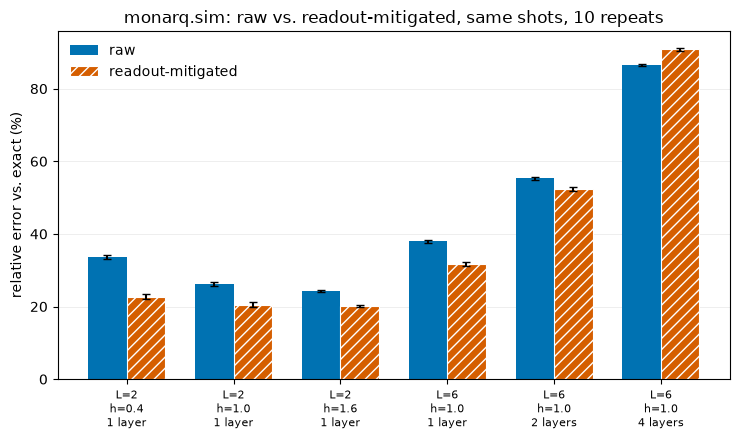

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(MITIGATION_POINTS))
width = 0.36
labels = [f"L={L}\nh={h}\n{n} layer" + ("s" if n > 1 else "") for L, h, n in MITIGATION_POINTS]
raw_err = [mitigation[p]["raw"]["rel_error"] * 100 for p in MITIGATION_POINTS]
raw_sem = [mitigation[p]["raw"]["rel_error_standard_error"] * 100 for p in MITIGATION_POINTS]
mit_err = [mitigation[p]["mitigated"]["rel_error"] * 100 for p in MITIGATION_POINTS]
mit_sem = [mitigation[p]["mitigated"]["rel_error_standard_error"] * 100 for p in MITIGATION_POINTS]

ax.bar(x - width / 2, raw_err, width, yerr=raw_sem, capsize=3, color=RAW_COLOR, label="raw")
ax.bar(x + width / 2, mit_err, width, yerr=mit_sem, capsize=3, color=MITIGATED_COLOR,
       hatch="///", edgecolor="white", linewidth=0.8, label="readout-mitigated")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("relative error vs. exact (%)")
ax.set_title("monarq.sim: raw vs. readout-mitigated, same shots, 10 repeats")
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_readout_mitigation.png", dpi=150)
plt.show()

Mitigation does help, substantially, at shallow depth — and the effect is far larger than the statistical error, so this is a real measurement rather than the shot-noise difference the earlier run was reading.

| point | raw error | mitigated error | change | paired ΔE |
|---|---|---|---|---|
| `L=2`, h=0.4, 1 layer | 33.73 ± 0.60% | **22.76 ± 0.75%** | −11.0 pp | −0.1404 ± 0.0025 (55σ) |
| `L=2`, h=1.0, 1 layer | 26.28 ± 0.49% | **20.54 ± 0.61%** | −5.7 pp | −0.1284 ± 0.0030 (43σ) |
| `L=2`, h=1.6, 1 layer | 24.39 ± 0.25% | **20.25 ± 0.30%** | −4.1 pp | −0.1390 ± 0.0021 (66σ) |
| `L=6`, h=1.0, 1 layer | 38.02 ± 0.40% | **31.67 ± 0.52%** | −6.3 pp | −0.4635 ± 0.0097 (48σ) |
| `L=6`, h=1.0, 2 layers | 55.35 ± 0.39% | **52.40 ± 0.51%** | −3.0 pp | −0.2148 ± 0.0094 (23σ) |
| `L=6`, h=1.0, 4 layers | 86.50 ± 0.33% | 90.82 ± 0.42% | **+4.3 pp** | **+0.3155 ± 0.0073 (43σ)** |

The benefit decays with depth and then reverses. At one layer the correction recovers 4 to 11 percentage points; by two layers it is down to 3; by four layers it makes the answer measurably *worse*. The reversal is not noise either — it is 43 standard errors on the paired difference.

The mechanism is the same in both directions. The correction amplifies the measured distribution's deviation from the calibration matrix's fixed point. At one layer a real signal survives, so what gets amplified is signal. At four layers only about 12% of the signal is left, so what gets amplified is mostly residual, and the energy is pushed further from the truth. Error mitigation applied to a measurement that has already lost its signal does not bring it back.

The old conclusion has to be dropped in both of its parts. Mitigation is not ineffective here; and the inference drawn from thinking it was — that readout error is ruled out, leaving gate and decoherence noise as the whole story — does not follow. At shallow depth readout error is a real and correctable share of the total. Gate noise still dominates, but it was never the only mechanism.

The two caveats above bound how far this travels, and they matter. The simulator inverts exactly the matrix it used to inject the readout noise, so these are best-case numbers: they measure how much of the error *is* readout error, which is the ceiling on what mitigation could recover, not a prediction of what it would recover on MonarQ itself.

A small detail from the verification, worth recording because it is what made the guard hard to get right: of the 420 corrections applied across these six points, 416 changed the counts and 4 did not. Both of those were genuine corrections — a distribution already sitting at the calibration matrix's fixed point moves by less than half a count and rounds straight back. That is why `VerifiedReadoutMitigation` decides whether the correction ran by object identity rather than by asking whether the numbers moved.

## Conclusion and hardware plan

The originally-planned `L = 2, 4, 6` ladder at the Phase 1-validated 10-layer depth is not viable. `L=6` already retains only 12% of the energy signal at 4 layers, and per-qubit gate load grows in proportion to depth, so 10 layers is far past the point where anything usable survives.

`L=2` at 1 layer is where the most signal survives — 33.1%, 35.1% and 44.8% error at `h` = 1.6, 1.0 and 0.4 under the generic noise model, and 24-34% under the calibrated one. Still a long way from exact, but a genuine measurement rather than noise-floor garbage, and the HVA reaches the exact ground state there in noiseless simulation, so all of the error is attributable to the device.

Submitted on that basis: `L=2`, `n_layers=1`, `h = 0.4, 1.0, 1.6` (ferromagnetic, critical, paramagnetic), 1000 shots, to the real `monarq.default` backend. Results below.

## Real hardware results

Loading the actual `monarq.default` measurements from `results/vqe_hardware/` alongside the `monarq.sim` prediction for the same exact configuration, to see how well the noise-model simulator actually predicted real hardware behaviour.

h     sim-predicted error         real hardware error   
0.4   44.81% +/- 0.55%            90.82%                
1.0   35.06% +/- 0.35%            74.42%                
1.6   33.05% +/- 0.52%            72.95%                


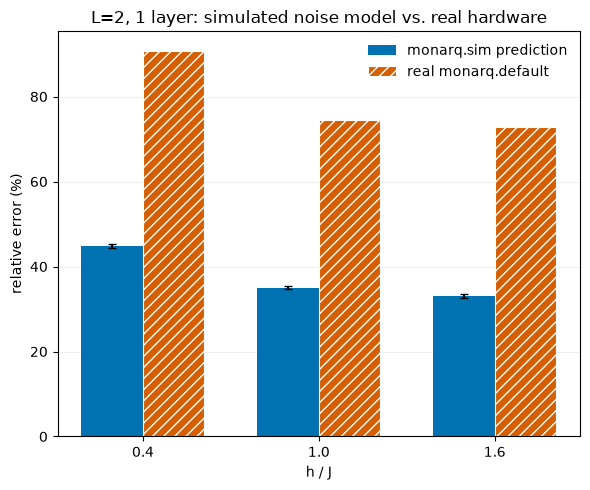

In [13]:
# Read the three archived hardware points by name. This directory also holds
# per-repeat files from a separate hardware run, which a glob would sweep up.
hw_records = {}
for h in (0.4, 1.0, 1.6):
    path = REPO_ROOT / "results" / "vqe_hardware" / "2" / f"{h:.3f}.json"
    hw_records[h] = json.loads(path.read_text())
sim_records = {h: records[(2, h, 1)] for h in hw_records}

print(f"{'h':<6}{'sim-predicted error':<28}{'real hardware error':<22}")
for h in sorted(hw_records):
    sim = sim_records[h]
    sim_s = f"{sim['rel_error_hardware_sim']:.2%} +/- {sim['rel_error_hardware_sim_standard_error']:.2%}"
    print(f"{h:<6}{sim_s:<28}{hw_records[h]['rel_error']:<22.2%}")

fig, ax = plt.subplots(figsize=(6, 5))
h_vals = sorted(hw_records)
x = np.arange(len(h_vals))
width = 0.35
sim_errs = [sim_records[h]["rel_error_hardware_sim"] * 100 for h in h_vals]
sim_sems = [sim_records[h]["rel_error_hardware_sim_standard_error"] * 100 for h in h_vals]
real_errs = [hw_records[h]["rel_error"] * 100 for h in h_vals]
ax.bar(x - width / 2, sim_errs, width, yerr=sim_sems, capsize=3,
       color=RAW_COLOR, label="monarq.sim prediction")
ax.bar(x + width / 2, real_errs, width, color=MITIGATED_COLOR, hatch="///",
       edgecolor="white", linewidth=0.8, label="real monarq.default")
ax.set_xticks(x)
ax.set_xticklabels([str(h) for h in h_vals])
ax.set_xlabel("h / J")
ax.set_ylabel("relative error (%)")
ax.set_title("L=2, 1 layer: simulated noise model vs. real hardware")
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_sim_vs_real.png", dpi=150)
plt.show()

Real hardware is consistently worse than the noise-model simulator predicted, at all three points — not a small gap. That is itself a useful finding rather than just a caveat: MonarQ's calibration-based noise model captures some of what makes this circuit hard but underestimates the total error meaningfully. The channel census above gives one concrete reason why, since the model carries no relaxation or dephasing at all; crosstalk and calibration drift between the benchmark pull and the job are others it also omits.

**Bottom line for Phase 3:** at the smallest, simplest point on the original ladder — 2 qubits, one HVA layer, a single logical two-qubit gate that the ansatz solves exactly in noiseless simulation — real MonarQ hardware still loses 73-91% of the energy signal.

What the corrected characterization adds is a sharper account of what controls that loss. It is not total two-qubit gate count, which does not even order the data. It is two-qubit gates per qubit, `4(L−1)n/L`, which rises in proportion to circuit depth but saturates as qubits are added — so depth is the binding constraint and qubit count a secondary one. Readout error is a real and correctable part of the total at shallow depth, worth 4 to 11 percentage points at one layer on the simulator's best-case terms, but its value decays with depth and by four layers the correction does more harm than good.

The honest Phase 3 result is not a clean hardware energy number. It is a quantified account of how much near-term hardware noise overwhelms this ansatz, which circuit property predicts it, how much of it is correctable in principle, and the fact that the gap is larger in practice than the calibration-based simulator predicts.